# Big Data Project

## Data Cleaning

### Importing required libraries 

In [244]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, isnan, when, count
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

spark = SparkSession.builder \
    .appName("Airline Passenger Satisfaction Analysis") \
    .getOrCreate()

spark

26/05/23 09:21:22 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


### Data Loading

In [143]:
df = spark.read.csv(
    "hdfs://namenode:9000/user/rinzin/airline_data/airline_satisfaction.csv",
    header=True,
    inferSchema=True
)
df.show(5)

+---+------+------+-----------------+---+---------------+--------+---------------+---------------------+---------------------------------+----------------------+-------------+--------------+---------------+------------+----------------------+----------------+----------------+----------------+---------------+----------------+-----------+--------------------------+------------------------+--------------------+
|_c0|    id|Gender|    Customer Type|Age| Type of Travel|   Class|Flight Distance|Inflight wifi service|Departure/Arrival time convenient|Ease of Online booking|Gate location|Food and drink|Online boarding|Seat comfort|Inflight entertainment|On-board service|Leg room service|Baggage handling|Checkin service|Inflight service|Cleanliness|Departure Delay in Minutes|Arrival Delay in Minutes|        satisfaction|
+---+------+------+-----------------+---+---------------+--------+---------------+---------------------+---------------------------------+----------------------+-------------+-

26/05/23 08:04:37 WARN CSVHeaderChecker: CSV header does not conform to the schema.
 Header: , id, Gender, Customer Type, Age, Type of Travel, Class, Flight Distance, Inflight wifi service, Departure/Arrival time convenient, Ease of Online booking, Gate location, Food and drink, Online boarding, Seat comfort, Inflight entertainment, On-board service, Leg room service, Baggage handling, Checkin service, Inflight service, Cleanliness, Departure Delay in Minutes, Arrival Delay in Minutes, satisfaction
 Schema: _c0, id, Gender, Customer Type, Age, Type of Travel, Class, Flight Distance, Inflight wifi service, Departure/Arrival time convenient, Ease of Online booking, Gate location, Food and drink, Online boarding, Seat comfort, Inflight entertainment, On-board service, Leg room service, Baggage handling, Checkin service, Inflight service, Cleanliness, Departure Delay in Minutes, Arrival Delay in Minutes, satisfaction
Expected: _c0 but found: 
CSV file: hdfs://namenode:9000/user/rinzin/airl

In [144]:
df = df.drop("_c0")

In [145]:
df.show(5)

+------+------+-----------------+---+---------------+--------+---------------+---------------------+---------------------------------+----------------------+-------------+--------------+---------------+------------+----------------------+----------------+----------------+----------------+---------------+----------------+-----------+--------------------------+------------------------+--------------------+
|    id|Gender|    Customer Type|Age| Type of Travel|   Class|Flight Distance|Inflight wifi service|Departure/Arrival time convenient|Ease of Online booking|Gate location|Food and drink|Online boarding|Seat comfort|Inflight entertainment|On-board service|Leg room service|Baggage handling|Checkin service|Inflight service|Cleanliness|Departure Delay in Minutes|Arrival Delay in Minutes|        satisfaction|
+------+------+-----------------+---+---------------+--------+---------------+---------------------+---------------------------------+----------------------+-------------+-------------

In [146]:
print(df.columns)

['id', 'Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [147]:
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Customer Type: string (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Type of Travel: string (nullable = true)
 |-- Class: string (nullable = true)
 |-- Flight Distance: integer (nullable = true)
 |-- Inflight wifi service: integer (nullable = true)
 |-- Departure/Arrival time convenient: integer (nullable = true)
 |-- Ease of Online booking: integer (nullable = true)
 |-- Gate location: integer (nullable = true)
 |-- Food and drink: integer (nullable = true)
 |-- Online boarding: integer (nullable = true)
 |-- Seat comfort: integer (nullable = true)
 |-- Inflight entertainment: integer (nullable = true)
 |-- On-board service: integer (nullable = true)
 |-- Leg room service: integer (nullable = true)
 |-- Baggage handling: integer (nullable = true)
 |-- Checkin service: integer (nullable = true)
 |-- Inflight service: integer (nullable = true)
 |-- Cleanliness: integer (nullable = true)
 |-- D

In [148]:
print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

Total Rows: 103904
Total Columns: 24


In [ ]:
df.select([
    count(when(col(c).isNull() | isnan(col(c)), c)).alias(c)
    for c in df.columns
]).show()

+---+------+-------------+---+--------------+-----+---------------+---------------------+---------------------------------+----------------------+-------------+--------------+---------------+------------+----------------------+----------------+----------------+----------------+---------------+----------------+-----------+--------------------------+------------------------+------------+
| id|Gender|Customer Type|Age|Type of Travel|Class|Flight Distance|Inflight wifi service|Departure/Arrival time convenient|Ease of Online booking|Gate location|Food and drink|Online boarding|Seat comfort|Inflight entertainment|On-board service|Leg room service|Baggage handling|Checkin service|Inflight service|Cleanliness|Departure Delay in Minutes|Arrival Delay in Minutes|satisfaction|
+---+------+-------------+---+--------------+-----+---------------+---------------------+---------------------------------+----------------------+-------------+--------------+---------------+------------+------------------

In [ ]:
df.filter(col("Arrival Delay in Minutes").isNull()).show()

+------+------+-----------------+---+---------------+--------+---------------+---------------------+---------------------------------+----------------------+-------------+--------------+---------------+------------+----------------------+----------------+----------------+----------------+---------------+----------------+-----------+--------------------------+------------------------+--------------------+
|    id|Gender|    Customer Type|Age| Type of Travel|   Class|Flight Distance|Inflight wifi service|Departure/Arrival time convenient|Ease of Online booking|Gate location|Food and drink|Online boarding|Seat comfort|Inflight entertainment|On-board service|Leg room service|Baggage handling|Checkin service|Inflight service|Cleanliness|Departure Delay in Minutes|Arrival Delay in Minutes|        satisfaction|
+------+------+-----------------+---+---------------+--------+---------------+---------------------+---------------------------------+----------------------+-------------+-------------

In [ ]:
df = df.withColumn(
    "Arrival Delay in Minutes",
    when(
        col("Arrival Delay in Minutes").isNull(),
        col("Departure Delay in Minutes")
    ).otherwise(col("Arrival Delay in Minutes"))
)

In [ ]:
df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    for c in df.columns
]).show()

+---+------+-------------+---+--------------+-----+---------------+---------------------+---------------------------------+----------------------+-------------+--------------+---------------+------------+----------------------+----------------+----------------+----------------+---------------+----------------+-----------+--------------------------+------------------------+------------+
| id|Gender|Customer Type|Age|Type of Travel|Class|Flight Distance|Inflight wifi service|Departure/Arrival time convenient|Ease of Online booking|Gate location|Food and drink|Online boarding|Seat comfort|Inflight entertainment|On-board service|Leg room service|Baggage handling|Checkin service|Inflight service|Cleanliness|Departure Delay in Minutes|Arrival Delay in Minutes|satisfaction|
+---+------+-------------+---+--------------+-----+---------------+---------------------+---------------------------------+----------------------+-------------+--------------+---------------+------------+------------------

In [153]:
df.groupBy("satisfaction").count().show()

+--------------------+-----+
|        satisfaction|count|
+--------------------+-----+
|neutral or dissat...|58879|
|           satisfied|45025|
+--------------------+-----+



In [154]:
# Remove unnecessary columns

columns_to_drop = ["Unnamed: 0", "id"]

existing_columns = [c for c in columns_to_drop if c in df.columns]

df = df.drop(*existing_columns)

print("Remaining Columns:", df.columns)

Remaining Columns: ['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'satisfaction']


In [155]:
# Clean column names

new_columns = []

for column in df.columns:
    clean_name = column.strip() \
                       .replace(" ", "_") \
                       .replace("/", "_") \
                       .replace("-", "_")
    
    new_columns.append(clean_name)

df = df.toDF(*new_columns)

print(df.columns)

['Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service', 'Departure_Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On_board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes', 'satisfaction']


In [156]:
total_rows = df.count()

unique_rows = df.dropDuplicates().count()

print("Total rows:", total_rows)
print("Unique rows:", unique_rows)
print("Duplicate rows:", total_rows - unique_rows)

Total rows: 103904
Unique rows: 103904
Duplicate rows: 0


In [ ]:
df = df.withColumn(
    "label",
    when(df["satisfaction"] == "satisfied", 1).otherwise(0)
)

In [158]:
df = df.withColumn(
    "gender_dummy",
    when(df["Gender"] == "Male", 1).otherwise(0)
)

In [159]:
df.show(5)

+------+-----------------+---+---------------+--------+---------------+---------------------+---------------------------------+----------------------+-------------+--------------+---------------+------------+----------------------+----------------+----------------+----------------+---------------+----------------+-----------+--------------------------+------------------------+--------------------+-----+------------+
|Gender|    Customer_Type|Age| Type_of_Travel|   Class|Flight_Distance|Inflight_wifi_service|Departure_Arrival_time_convenient|Ease_of_Online_booking|Gate_location|Food_and_drink|Online_boarding|Seat_comfort|Inflight_entertainment|On_board_service|Leg_room_service|Baggage_handling|Checkin_service|Inflight_service|Cleanliness|Departure_Delay_in_Minutes|Arrival_Delay_in_Minutes|        satisfaction|label|gender_dummy|
+------+-----------------+---+---------------+--------+---------------+---------------------+---------------------------------+----------------------+----------

In [160]:
total = df.count()

df.groupBy("label").count() \
    .withColumn("percentage", (col("count") / total) * 100) \
    .show()

+-----+-----+------------------+
|label|count|        percentage|
+-----+-----+------------------+
|    1|45025|43.333269171542966|
|    0|58879|56.666730828457034|
+-----+-----+------------------+



In [161]:
# 3. Numeric Columns
num_cols = [
    "Age",
    "Flight_Distance",
    "Inflight_wifi_service",
    "Departure_Arrival_time_convenient",
    "Ease_of_Online_booking",
    "Gate_location",
    "Food_and_drink",
    "Online_boarding",
    "Seat_comfort",
    "Inflight_entertainment",
    "On_board_service",
    "Leg_room_service",
    "Baggage_handling",
    "Checkin_service",
    "Inflight_service",
    "Cleanliness",
    "Departure_Delay_in_Minutes",
    "Arrival_Delay_in_Minutes"
]

# 4. Convert to numeric (double)
for c in num_cols:
    df = df.withColumn(c, col(c).cast("double"))

# 5. IQR Outlier Function
def get_outliers(df, col_name):
    q1, q3 = df.approxQuantile(col_name, [0.25, 0.75], 0.01)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = df.filter((col(col_name) < lower) | (col(col_name) > upper)).count()

    return (col_name, lower, upper, count)

# 6. Run Outlier Detection
results = []

for c in num_cols:
    results.append(get_outliers(df, c))

# 7. Create Result Table
outlier_df = spark.createDataFrame(
    results,
    ["Feature", "Lower_Bound", "Upper_Bound", "Outlier_Count"]
)

outlier_df.show(truncate=False)

+---------------------------------+-----------+-----------+-------------+
|Feature                          |Lower_Bound|Upper_Bound|Outlier_Count|
+---------------------------------+-----------+-----------+-------------+
|Age                              |-7.5       |84.5       |17           |
|Flight_Distance                  |-1531.0    |3653.0     |2948         |
|Inflight_wifi_service            |-1.0       |7.0        |0            |
|Departure_Arrival_time_convenient|-1.0       |7.0        |0            |
|Ease_of_Online_booking           |-1.0       |7.0        |0            |
|Gate_location                    |-1.0       |7.0        |0            |
|Food_and_drink                   |-1.0       |7.0        |0            |
|Online_boarding                  |-1.0       |7.0        |0            |
|Seat_comfort                     |-1.0       |7.0        |0            |
|Inflight_entertainment           |-1.0       |7.0        |0            |
|On_board_service                 |-1.

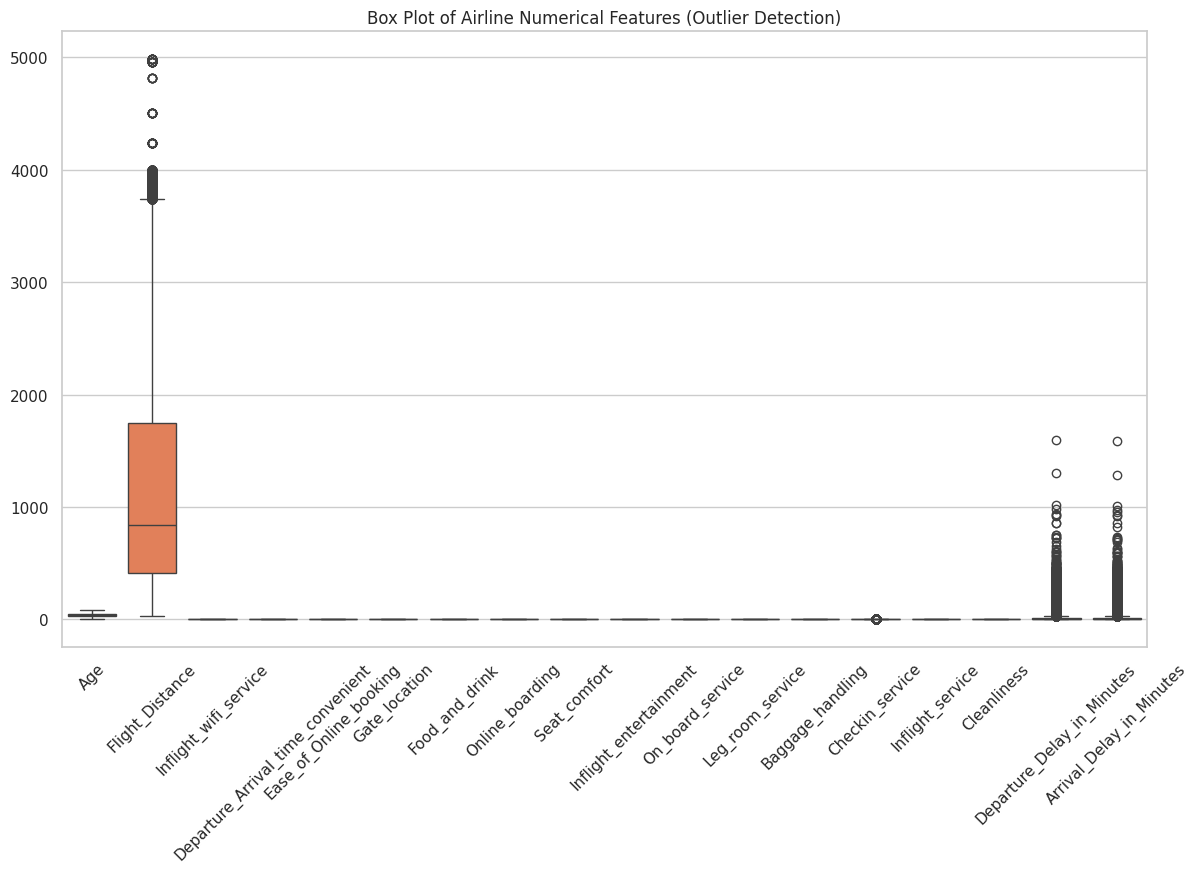

In [162]:
# 3. Numeric Columns
num_cols = [
    "Age",
    "Flight_Distance",
    "Inflight_wifi_service",
    "Departure_Arrival_time_convenient",
    "Ease_of_Online_booking",
    "Gate_location",
    "Food_and_drink",
    "Online_boarding",
    "Seat_comfort",
    "Inflight_entertainment",
    "On_board_service",
    "Leg_room_service",
    "Baggage_handling",
    "Checkin_service",
    "Inflight_service",
    "Cleanliness",
    "Departure_Delay_in_Minutes",
    "Arrival_Delay_in_Minutes"
]

# 4. Cast to numeric
for c in num_cols:
    df = df.withColumn(c, col(c).cast("double"))

# 5. Convert to Pandas (for plotting)
pdf = df.select(num_cols).toPandas()

# 6. Box Plots
plt.figure(figsize=(14,8))

sns.boxplot(data=pdf)

plt.xticks(rotation=45)
plt.title("Box Plot of Airline Numerical Features (Outlier Detection)")
plt.show()

Mean Values:
Age                                 -6.130999e-15
Flight_Distance                     -1.042454e-15
Inflight_wifi_service                2.444269e-15
Departure_Arrival_time_convenient    1.621945e-15
Ease_of_Online_booking               6.148112e-15
Gate_location                       -3.426066e-15
Food_and_drink                       1.257168e-14
Online_boarding                     -1.349145e-14
Seat_comfort                         5.673318e-15
Inflight_entertainment              -4.419795e-15
On_board_service                     5.589684e-15
Leg_room_service                    -5.931402e-15
Baggage_handling                     6.428420e-15
Checkin_service                      1.029847e-14
Inflight_service                    -1.657081e-14
Cleanliness                         -1.254911e-14
Departure_Delay_in_Minutes          -6.087592e-16
Arrival_Delay_in_Minutes            -4.811536e-16
dtype: float64

Standard Deviation:
Age                                  1.0
Flight_Dis

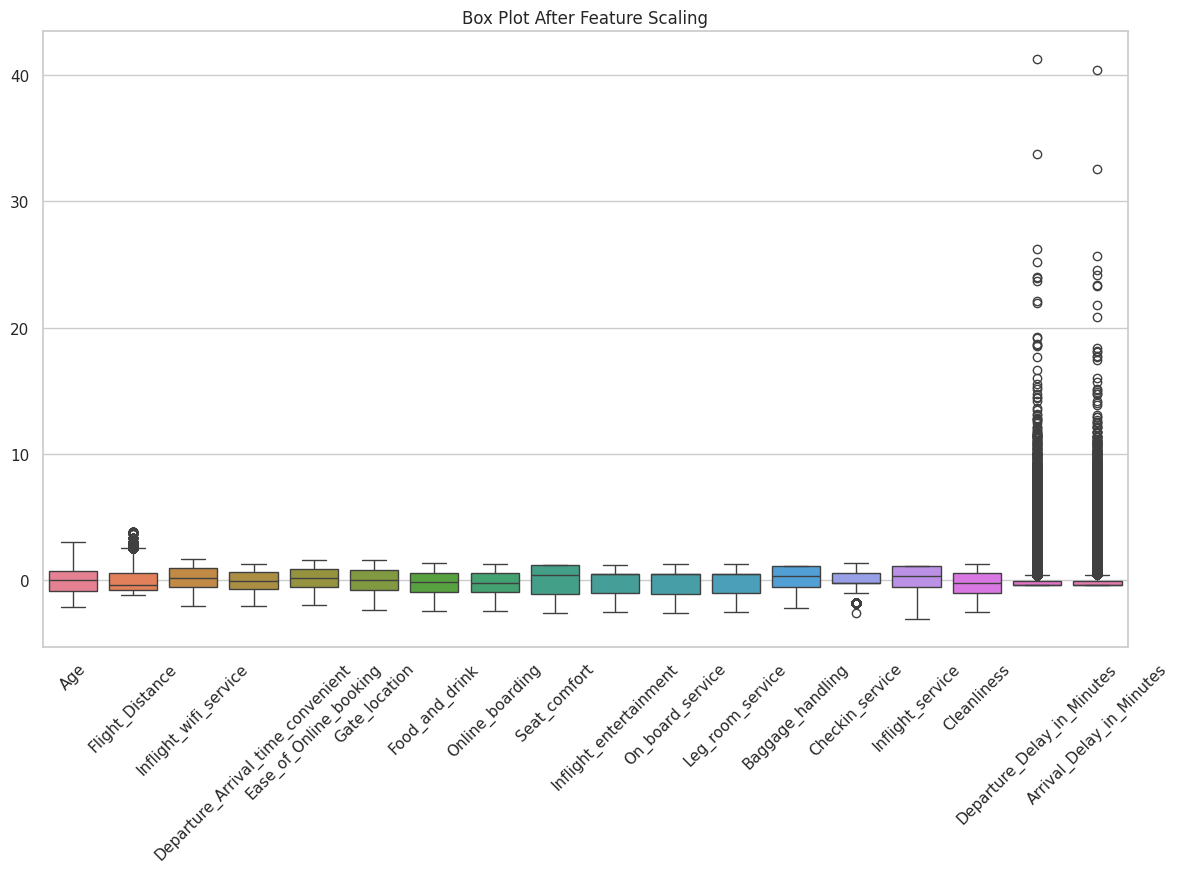

In [ ]:
# Assemble features
assembler = VectorAssembler(
    inputCols=num_cols,
    outputCol="features"
)

data = assembler.transform(df)

# Apply Standard Scaling
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaledFeatures",
    withStd=True,
    withMean=True
)

scalerModel = scaler.fit(data)

scaledData = scalerModel.transform(data)

# Convert vector to array
scaled_df = scaledData.withColumn(
    "scaled_array",
    vector_to_array(col("scaledFeatures"))
)


# Convert to Pandas
scaled_pdf = scaled_df.select("scaled_array").toPandas()

# Create DataFrame
scaled_values = pd.DataFrame(
    scaled_pdf["scaled_array"].tolist(),
    columns=num_cols
)

# Display Mean and Standard Deviation
print("Mean Values:")
print(scaled_values.mean())

print("\nStandard Deviation:")
print(scaled_values.std())

# Box Plot After Scaling
plt.figure(figsize=(14,8))

sns.boxplot(data=scaled_values)

plt.xticks(rotation=45)

plt.title("Box Plot After Feature Scaling")

plt.show()

In [164]:
total_rows = df.count()
print("Total rows:", total_rows)

Total rows: 103904


# Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql.functions import col, round

# For safe plotting
sns.set(style="whitegrid")

In [91]:
# Show all column names
print(df.columns)

['Gender', 'Customer_Type', 'Age', 'Type_of_Travel', 'Class', 'Flight_Distance', 'Inflight_wifi_service', 'Departure_Arrival_time_convenient', 'Ease_of_Online_booking', 'Gate_location', 'Food_and_drink', 'Online_boarding', 'Seat_comfort', 'Inflight_entertainment', 'On_board_service', 'Leg_room_service', 'Baggage_handling', 'Checkin_service', 'Inflight_service', 'Cleanliness', 'Departure_Delay_in_Minutes', 'Arrival_Delay_in_Minutes', 'satisfaction', 'satisfaction_index', 'satisfaction_dummy', 'label', 'gender_dummy']


### Satisfaction Percentage Analysis

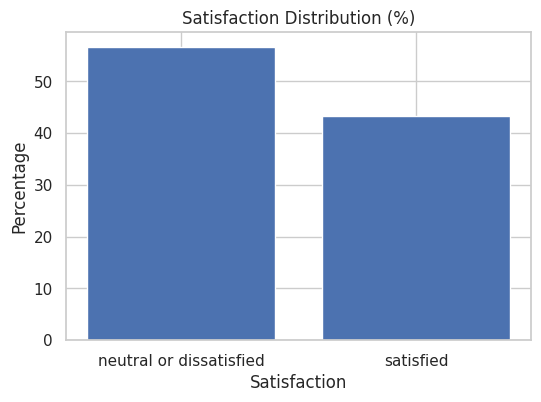

In [ ]:
total = df.count()

result = df.groupBy("satisfaction") \
    .count() \
    .withColumn("Percentage", round((col("count") / total) * 100, 2))

pdf = result.toPandas()

plt.figure(figsize=(6,4))

plt.bar(pdf["satisfaction"], pdf["Percentage"])

plt.title("Satisfaction Distribution (%)")
plt.xlabel("Satisfaction")
plt.ylabel("Percentage")

plt.show()

### Gender Distribution 

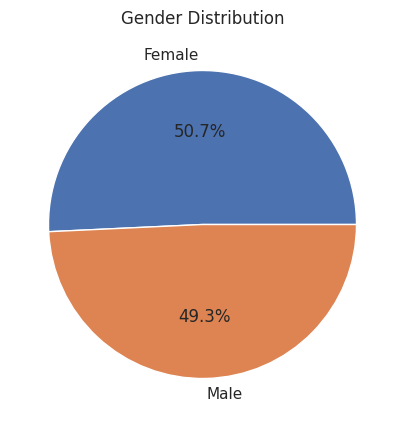

In [93]:
gender_pd = df.groupBy(
    "Gender"
).count().toPandas()

plt.figure(figsize=(6,5))

plt.pie(
    gender_pd["count"],
    labels=gender_pd["Gender"],
    autopct='%1.1f%%'
)

plt.title("Gender Distribution")

plt.show()

### Customer Type vs Satisfaction

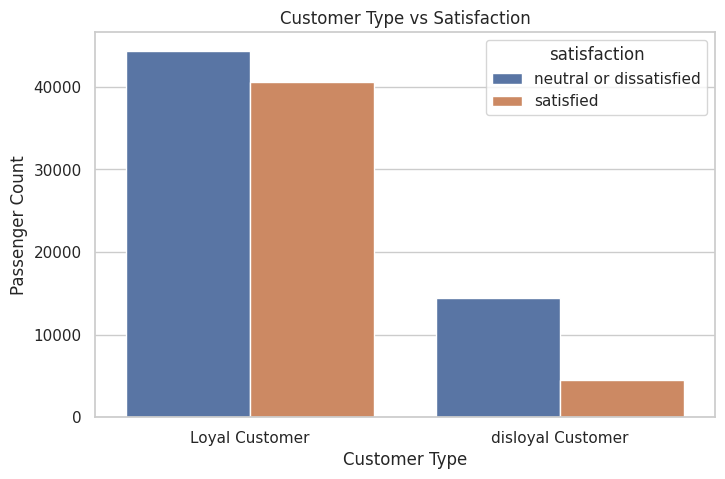

In [94]:
customer_pd = df.groupBy(
    "Customer_Type",
    "satisfaction"
).count().toPandas()

plt.figure(figsize=(8,5))

sns.barplot(
    data=customer_pd,
    x="Customer_Type",
    y="count",
    hue="satisfaction"
)

plt.title("Customer Type vs Satisfaction")
plt.xlabel("Customer Type")
plt.ylabel("Passenger Count")

plt.show()

### Travel Type Analysis

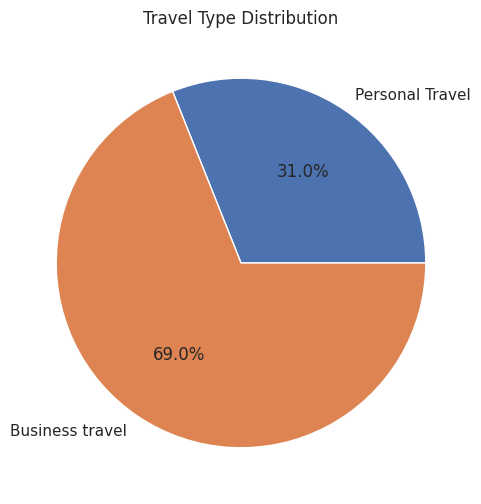

In [95]:
travel_pd = df.groupBy(
    "Type_of_Travel"
).count().toPandas()

plt.figure(figsize=(6,6))

plt.pie(
    travel_pd["count"],
    labels=travel_pd["Type_of_Travel"],
    autopct='%1.1f%%'
)

plt.title("Travel Type Distribution")

plt.show()

### Travel Class vs Satisfaction

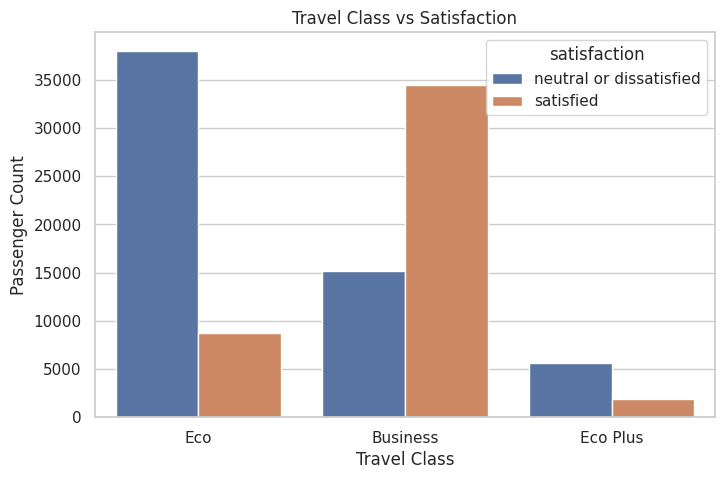

In [96]:
class_pd = df.groupBy(
    "Class",
    "satisfaction"
).count().toPandas()

plt.figure(figsize=(8,5))

sns.barplot(
    data=class_pd,
    x="Class",
    y="count",
    hue="satisfaction"
)

plt.title("Travel Class vs Satisfaction")
plt.xlabel("Travel Class")
plt.ylabel("Passenger Count")

plt.show()

### Age Distribution

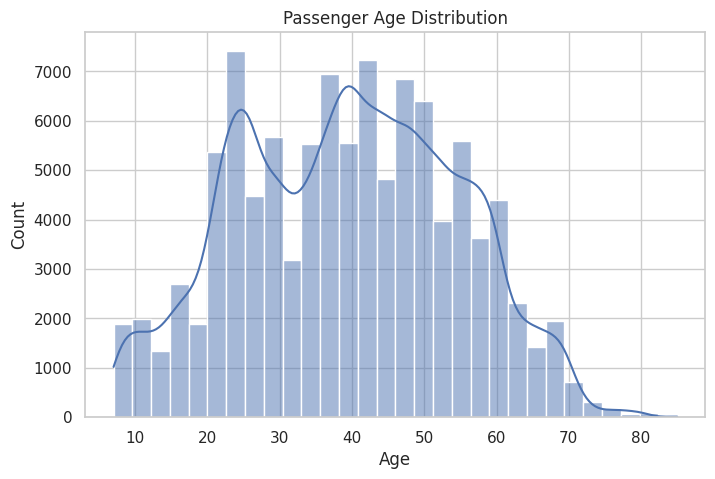

In [97]:
age_pd = df.select("Age").toPandas()

plt.figure(figsize=(8,5))

sns.histplot(
    age_pd["Age"],
    bins=30,
    kde=True
)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")

plt.show()

### Flight Distance Distribution

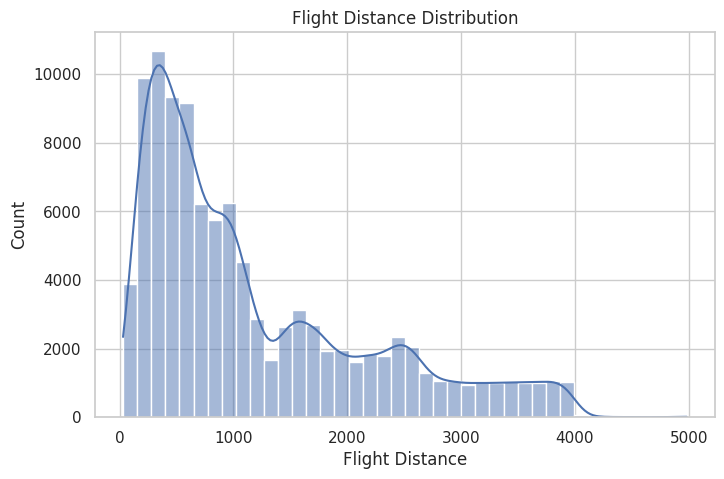

In [98]:
distance_pd = df.select(
    "Flight_Distance"
).toPandas()

plt.figure(figsize=(8,5))

sns.histplot(
    distance_pd["Flight_Distance"],
    bins=40,
    kde=True
)

plt.title("Flight Distance Distribution")
plt.xlabel("Flight Distance")

plt.show()

### Delay Distribution Analysis

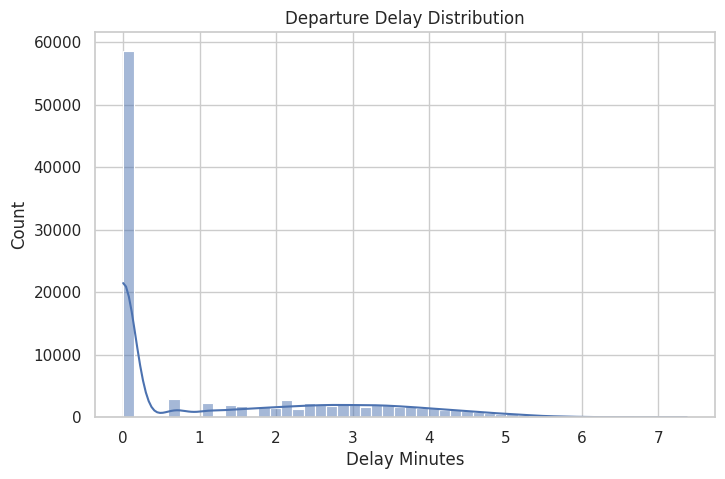

In [99]:
delay_pd = df.select(
    "Departure_Delay_in_Minutes"
).toPandas()

plt.figure(figsize=(8,5))

sns.histplot(
    delay_pd["Departure_Delay_in_Minutes"],
    bins=50,
    kde=True
)

plt.title("Departure Delay Distribution")
plt.xlabel("Delay Minutes")

plt.show()

### Satisfaction vs Arrival Delay

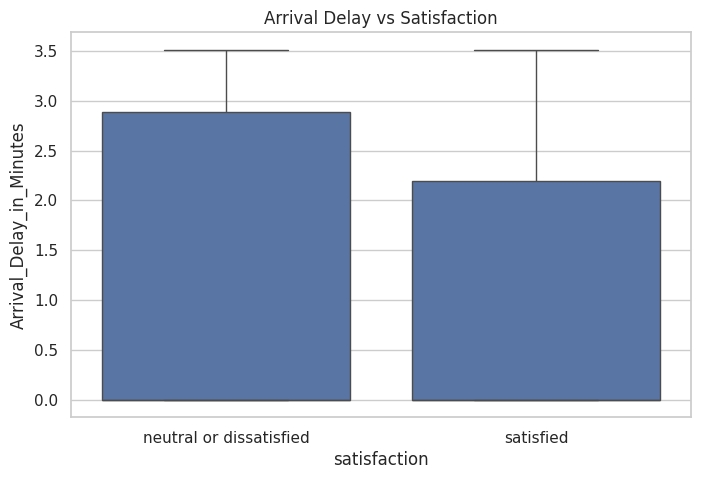

In [100]:
delay_satisfaction_pd = df.select(
    "satisfaction",
    "Arrival_Delay_in_Minutes"
).toPandas()

plt.figure(figsize=(8,5))

sns.boxplot(
    data=delay_satisfaction_pd,
    x="satisfaction",
    y="Arrival_Delay_in_Minutes"
)

plt.title("Arrival Delay vs Satisfaction")

plt.show()

### Service Ratings Analysis

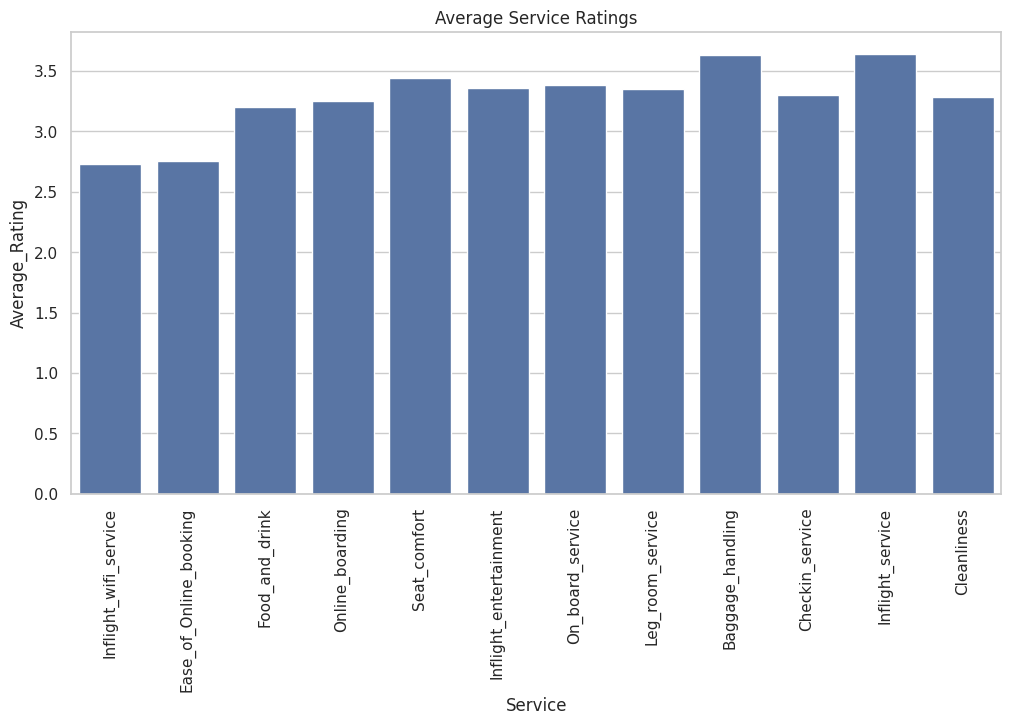

In [101]:
service_columns = [
    "Inflight_wifi_service",
    "Ease_of_Online_booking",
    "Food_and_drink",
    "Online_boarding",
    "Seat_comfort",
    "Inflight_entertainment",
    "On_board_service",
    "Leg_room_service",
    "Baggage_handling",
    "Checkin_service",
    "Inflight_service",
    "Cleanliness"
]

service_means = []

for column in service_columns:
    
    avg_rating = df.select(column).toPandas()[column].mean()
    
    service_means.append({
        "Service": column,
        "Average_Rating": avg_rating
    })

service_df = pd.DataFrame(service_means)

plt.figure(figsize=(12,6))

sns.barplot(
    data=service_df,
    x="Service",
    y="Average_Rating"
)

plt.xticks(rotation=90)

plt.title("Average Service Ratings")

plt.show()

### Correlation Heatmap

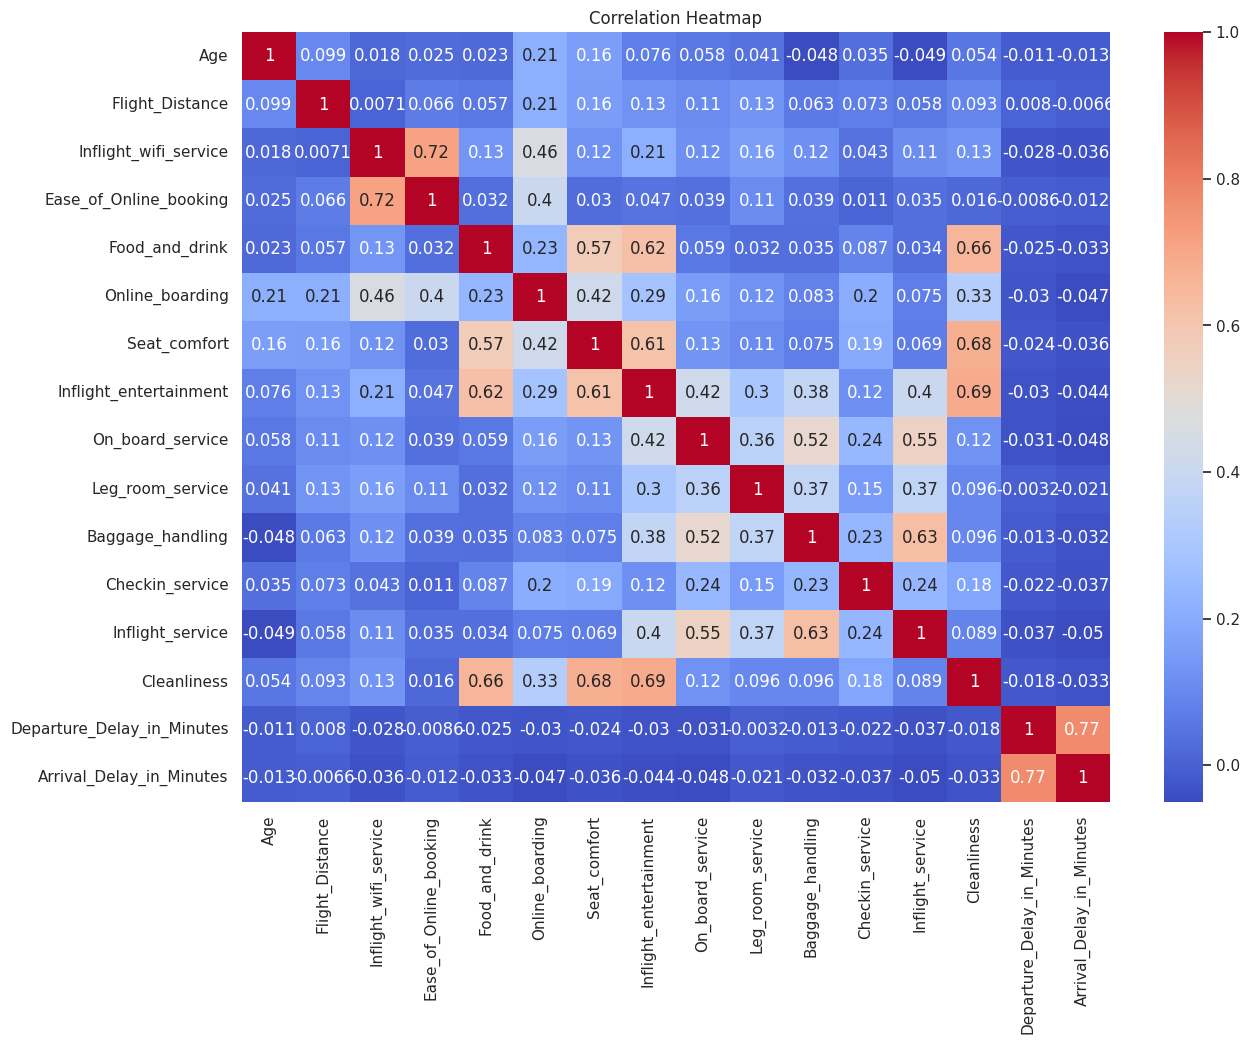

In [102]:
numeric_columns = [
    "Age",
    "Flight_Distance",
    "Inflight_wifi_service",
    "Ease_of_Online_booking",
    "Food_and_drink",
    "Online_boarding",
    "Seat_comfort",
    "Inflight_entertainment",
    "On_board_service",
    "Leg_room_service",
    "Baggage_handling",
    "Checkin_service",
    "Inflight_service",
    "Cleanliness",
    "Departure_Delay_in_Minutes",
    "Arrival_Delay_in_Minutes"
]

corr_pd = df.select(
    numeric_columns
).toPandas()

correlation_matrix = corr_pd.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Top Factors Affecting Satisfaction

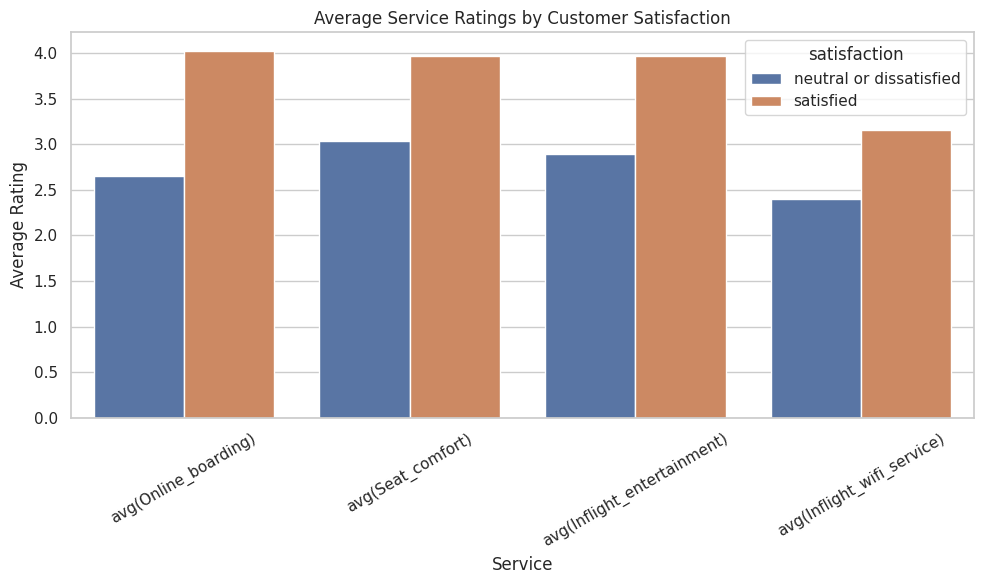

In [103]:
satisfaction_services = df.groupBy(
    "satisfaction"
).avg(
    "Online_boarding",
    "Seat_comfort",
    "Inflight_entertainment",
    "Inflight_wifi_service"
)

pdf = satisfaction_services.toPandas()

pdf_melted = pdf.melt(
    id_vars="satisfaction",
    var_name="Service",
    value_name="Average Rating"
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=pdf_melted,
    x="Service",
    y="Average Rating",
    hue="satisfaction"
)

plt.title("Average Service Ratings by Customer Satisfaction")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [104]:
# Remove vector/struct columns before saving

save_df = scaledData.drop(
    "features",
    "scaledFeatures",
    "scaled_array",
    "satisfaction_dummy"
)

# Save cleaned dataset
save_df.write.mode("overwrite").option(
    "header",
    True
).csv("cleaned_airline_dataset")

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Model Building

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier
)
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

spark = SparkSession.builder.appName("AirlineSatisfactionModel").getOrCreate()

df = spark.read.csv("cleaned_airline_dataset", header=True, inferSchema=True)
df.show(5)

26/05/23 08:43:00 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


+------+-----------------+----+---------------+--------+---------------+---------------------+---------------------------------+----------------------+-------------+--------------+---------------+------------+----------------------+----------------+----------------+----------------+---------------+----------------+-----------+--------------------------+------------------------+--------------------+------------------+-----+------------+
|Gender|    Customer_Type| Age| Type_of_Travel|   Class|Flight_Distance|Inflight_wifi_service|Departure_Arrival_time_convenient|Ease_of_Online_booking|Gate_location|Food_and_drink|Online_boarding|Seat_comfort|Inflight_entertainment|On_board_service|Leg_room_service|Baggage_handling|Checkin_service|Inflight_service|Cleanliness|Departure_Delay_in_Minutes|Arrival_Delay_in_Minutes|        satisfaction|satisfaction_index|label|gender_dummy|
+------+-----------------+----+---------------+--------+---------------+---------------------+--------------------------

#### Feature Selection

In [ ]:
feature_cols = [
    "Age",
    "Flight_Distance",
    "Inflight_wifi_service",
    "Departure_Arrival_time_convenient",
    "Ease_of_Online_booking",
    "Gate_location",
    "Food_and_drink",
    "Online_boarding",
    "Seat_comfort",
    "Inflight_entertainment",
    "On_board_service",
    "Leg_room_service",
    "Baggage_handling",
    "Checkin_service",
    "Inflight_service",
    "Cleanliness",
    "Departure_Delay_in_Minutes",
    "Arrival_Delay_in_Minutes"
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

df_ml = assembler.transform(df).select("features", "label")

train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)

In [ ]:
evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="accuracy"
)

### Logistic Regression Model

In [236]:
lr = LogisticRegression(featuresCol="features", labelCol="label")
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)
evaluator = BinaryClassificationEvaluator(labelCol="label")
print("Logistic Regression:", evaluator.evaluate(lr_predictions))

Logistic Regression: 0.8918484279748126


### Decision Tree Classifier

In [237]:
dt = DecisionTreeClassifier(featuresCol="features", labelCol="label")
dt_model = dt.fit(train_data)
dt_predictions = dt_model.transform(test_data)
evaluator = BinaryClassificationEvaluator(labelCol="label")
print("Decision Tree:", evaluator.evaluate(dt_predictions))

Decision Tree: 0.7628024379922279


### Random Forest Classifier

In [238]:
rf = RandomForestClassifier(featuresCol="features", labelCol="label")
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
evaluator = BinaryClassificationEvaluator(labelCol="label")
print("Random Forest:", evaluator.evaluate(rf_predictions))

Random Forest: 0.9527568240445949


### Gradient Boosting Classifier (GBT)

In [239]:
gbt = GBTClassifier(featuresCol="features", labelCol="label", maxIter=20)
gbt_model = gbt.fit(train_data)
gbt_predictions = gbt_model.transform(test_data)
evaluator = BinaryClassificationEvaluator(labelCol="label")
print("Gradient Boosting:", evaluator.evaluate(gbt_predictions))

Gradient Boosting: 0.9721842421560217


#### Confusion Matrix

In [240]:
def confusion_matrix(predictions):
    return predictions.groupBy("label") \
        .pivot("prediction", [0, 1]) \
        .count() \
        .fillna(0) \
        .orderBy("label")


# ---------------- RANDOM FOREST ----------------
print("\n================ Random Forest Confusion Matrix ================\n")
confusion_matrix(rf_predictions).show()

# ---------------- LOGISTIC REGRESSION ----------------
print("\n================ Logistic Regression Confusion Matrix ================\n")
confusion_matrix(lr_predictions).show()

# ---------------- DECISION TREE ----------------
print("\n================ Decision Tree Confusion Matrix ================\n")
confusion_matrix(dt_predictions).show()



================ Random Forest Confusion Matrix ================

+-----+-----+----+
|label|    0|   1|
+-----+-----+----+
|    0|10663|1071|
|    1| 1281|7691|
+-----+-----+----+


================ Logistic Regression Confusion Matrix ================

+-----+-----+----+
|label|    0|   1|
+-----+-----+----+
|    0|10153|1581|
|    1| 1894|7078|
+-----+-----+----+


================ Decision Tree Confusion Matrix ================

+-----+-----+----+
|label|    0|   1|
+-----+-----+----+
|    0|10637|1097|
|    1| 1605|7367|
+-----+-----+----+



In [241]:
# ---------------- GRADIENT BOOSTING ----------------
print("\n================ Gradient Boosting Confusion Matrix ================\n")
confusion_matrix(gbt_predictions).show()


================ Gradient Boosting Confusion Matrix ================

+-----+-----+----+
|label|    0|   1|
+-----+-----+----+
|    0|10950| 784|
|    1|  999|7973|
+-----+-----+----+



### Actual vs Predicted Graph

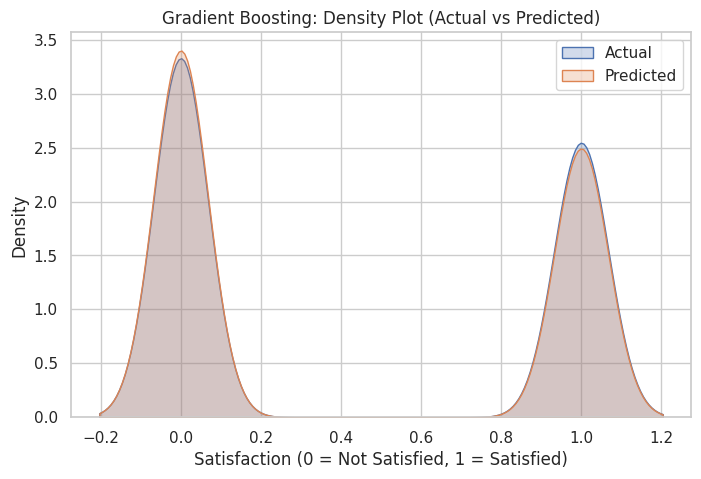

In [242]:
gb_df = gbt_predictions.select("label", "prediction").toPandas()
plt.figure(figsize=(8,5))

sns.kdeplot(gb_df["label"], label="Actual", fill=True)
sns.kdeplot(gb_df["prediction"], label="Predicted", fill=True)

plt.title("Gradient Boosting: Density Plot (Actual vs Predicted)")
plt.xlabel("Satisfaction (0 = Not Satisfied, 1 = Satisfied)")
plt.ylabel("Density")

plt.legend()
plt.show()

In [243]:
from pyspark.ml import Pipeline
gbt = GBTClassifier(featuresCol="features", labelCol="label")

pipeline = Pipeline(stages=[assembler, gbt])

pipeline_model = pipeline.fit(df)

pipeline_model.save("gbt_pipeline_model")